In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
data = pd.read_csv("/content/btcusd_1-min_data.csv")
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [ ]:
# Convert timestamp to readable date
data['Timestamp'] = pd.to_datetime(data['Timestamp'], unit='s')

# Sort by time
data = data.sort_values('Timestamp')

# Select only Close price
data = data[['Close']]

print("Data Loaded Successfully")
print(data.head())




Data Loaded Successfully
   Close
0   4.58
1   4.58
2   4.58
3   4.58
4   4.58


In [ ]:
# 2. Normalize Data
# ==========================================

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [ ]:

# ==========================================
# 3. Create Sequences (Past 60 days → Next day)
# ==========================================

def create_dataset(dataset, time_step=60):

    X = []
    y = []

    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)


time_step = 60
X, y = create_dataset(scaled_data, time_step)

print("Total samples created:", len(X))

Total samples created: 5059512


In [ ]:
# ==========================================
# 4. Reduce Dataset Size (Important for large data)
# ==========================================

X = X[-100000:]   # use last 100k samples
y = y[-100000:]

In [ ]:
# ==========================================
# 5. Split Data into Train and Test
# ==========================================

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (80000, 60)
Testing Data Shape: (20000, 60)


In [ ]:
# ==========================================
# 6. Build LSTM Model
# ==========================================

model = Sequential()

model.add(Input(shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

print("Training Started...")
model.fit(X_train, y_train, epochs=5, batch_size=32)


Training Started...
Epoch 1/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 58s 22ms/step - loss: 0.0076
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 54s 22ms/step - loss: 3.4166e-06
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 53s 21ms/step - loss: 5.0072e-06
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 52s 21ms/step - loss: 3.9958e-06
Epoch 5/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 86s 22ms/step - loss: 3.4924e-06


In [ ]:
# ==========================================
# 7. Make Predictions
# ==========================================

predictions = model.predict(X_test)

# Convert back to original scale
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step


In [ ]:
# ==========================================
# 8. Evaluate Model
# ==========================================

predictions = np.nan_to_num(predictions)
y_test_actual = np.nan_to_num(y_test_actual)

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 366.8674361715175
MAE: 138.20829716406246


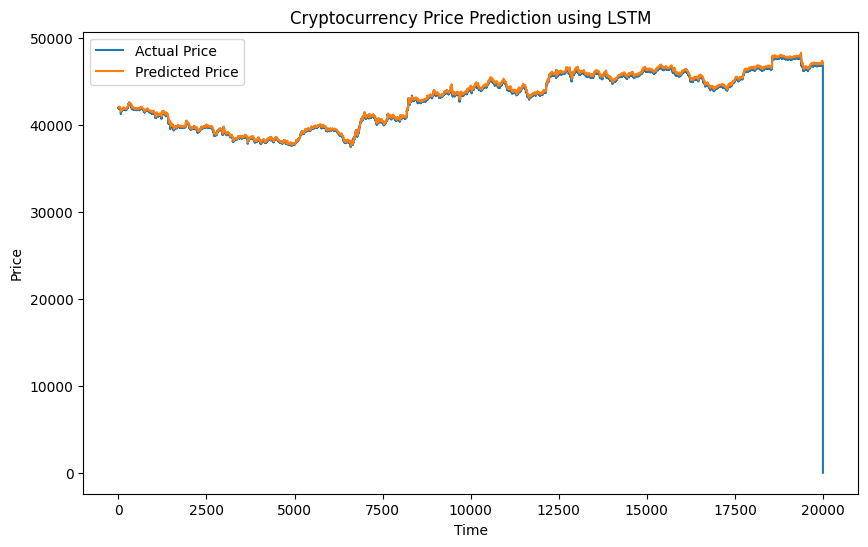

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.title("Cryptocurrency Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()